# H₂ / 6-31G / K=4 —— 化学精度连续达标 · 动态追加冻结版

基于 `h2-6-31G-K4-冻结版.ipynb` 改造，两处核心变化：

## 1. 能量计算统一使用 `compute_lam_v_from_samples`
每轮用当前 MCMC 样本构造 K×K 的 M̂、Ŝ，解广义本征问题 `M v = λ S v`，
得到各能级能量 `lam_real`（能量升序）与旋转矩阵 `v`，
不再用 `E_L_mean` 的本征分解作为能量监控来源。

## 2. 逐能级"连续 5 轮化学精度 → 单向冻结"（OneWayFreezer）
- 每轮统计各能级误差 `err_j = |λ_j − E_j^exact|`；
- **逐能级独立计数** `acc_rounds[j]`：达标 +1；任何一轮不达标立即清零（保证"连续"）；
- 能级 j **连续 `FREEZE_PATIENCE = 5` 轮**达标 → 用 `level_to_active_col(v, j)` 找到
  该能级最对齐的主动列，调用 `freeze_ctrl.freeze_cols(col_j)` 冻结；
- 冻结是**单向、永不恢复**的（OneWayFreezer：frozen_set 只增不减）；
- **追加冻结**：后续其他能级陆续连续 5 轮达标时，自动再冻结其对应列；
  每次新增冻结 → `consume_changed()` 触发 `grad_fn / qgt_fn / idx_active` 重建，
  活跃参数 P_a 单调下降，QGT 规模从 P² 缩到 P_a²。

In [1]:
import logging
import os
import time
import pickle

import numpy as np

import jax
import jax.numpy as jnp
import flax.nnx as nnx
import netket as nk
import optax

from NES_VMC_V1 import (
    NESTotalAnsatz_stable,
    create_single_machine_gauge_fixed,
    NESFermionHopRule,
    ravel_pytree,
)
from NES_VMC_tool import make_grad_fn_gauge, make_gauge_fn, \
    make_MS_estimator_fn, compute_lam_v_from_samples, level_to_active_col
from NES_VMC_frozen import (
    create_gauge_reset_total_machines,
    make_qgt_fn_gauge_frozen,
    build_active_index,
)
from NES_VMC_frozen_dynamic import OneWayFreezer
from H2_631G import SINGLE_SIZE, ha, hi_ext, ext_edges, K, Hatree_Fock, hi, E_fcis

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: You can use flax.linen, flax.nnx and equinox to define neural networks.

H2 分子基本信息
HF energy = -0.99749729 Ha
Total electrons = (1, 1)
Total basis functions = 4
H₂ FCI 基准能量
E0 = -1.05434745 Ha  |  激发能: 0.0000 eV
E1 = -0.95790573 Ha  |  激发能: 2.6243 eV
E2 = -0.66895227 Ha  |  激发能: 10.4871 eV
E3 = -0.55140192 Ha  |  激发能: 13.6859 eV

HF reference state: [0 0 0 1 0 0 0 1]
single_edges: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3), (4, 5), (4, 6), (4, 7), (5, 6), (5, 7), (6, 7)]


In [2]:
time_str = time.strftime("%y-%m-%d-%H-%M")
logger = logging.getLogger("NES_VMC_K4_H2_chemacc_freeze")
logger.setLevel(logging.INFO)
logger.propagate = False
logger.handlers.clear()
simple_formatter = logging.Formatter("%(asctime)s %(message)s", datefmt="%y-%d-%H-%M")

os.makedirs("./日志", exist_ok=True)
log_path = f"./日志/{time_str}_nes_vmc_K4_H2_6-31G_chemacc_freeze.log"
file_handler = logging.FileHandler(log_path, mode="w", encoding="utf-8")
file_handler.setFormatter(simple_formatter)
logger.addHandler(file_handler)

console_handler = logging.StreamHandler()
console_handler.setFormatter(simple_formatter)
logger.addHandler(console_handler)

In [3]:
# ====================== 超参配置 ======================
N_CHAINS = 16
N_SAMPLES_PER_CHAIN = 200
SWEEP_SIZE = 10
N_ITER = 300
Natural_Grad = True
clip_norm = 20.0
lr = 0.1
qgt_diag_shift = 0.1
RESET_PERIOD = 10
SAVE_INTERVAL = 20
HISTORY_FILE = f"./data/{time_str}_history_chemacc_freeze_H2_molecule_K4.pkl"
os.makedirs("./data", exist_ok=True)

# ---- 化学精度连续达标 → 单向冻结 的机制参数 ----
chemical_accuracy = 0.0016   # 化学精度（Ha）
FREEZE_PATIENCE = 5          # 连续达标轮数阈值：连续 5 轮 → 冻结，永不恢复

# 逐能级冻结状态（训练循环内维护）
acc_rounds = [0] * K         # 各能级"连续达到化学精度"的轮数计数器（不达标立即清零）
level_done = [False] * K     # 该能级是否已触发冻结（单向；触发后不再计数）
freeze_events = []           # 冻结事件记录：{"step", "level", "col", "err"}

# ====================== 模型与采样器 ======================
total_ansatz = NESTotalAnsatz_stable(
    n_spin_orbitals=SINGLE_SIZE,
    n_states=K,
    hidden_dim=SINGLE_SIZE + K,
    rngs=nnx.Rngs(11),
)
g_current = jnp.zeros(K, dtype=jnp.complex64)

total_machine, total_matrix_machine, total_max_machine, _, total_params = \
    create_gauge_reset_total_machines(total_ansatz, Hatree_Fock)

single_machine_list = [
    create_single_machine_gauge_fixed(ansatz, Hatree_Fock)[0]
    for ansatz in total_ansatz.single_ansatz_list
]

def build_grad_machines(frozen_mask):
    tm, tmm, tmmax, _, _ = create_gauge_reset_total_machines(
        total_ansatz, Hatree_Fock, frozen_mask=frozen_mask
    )
    grad_fn = make_grad_fn_gauge(ha, tmm, tmmax, tm, single_machine_list)
    qgt_fn = make_qgt_fn_gauge_frozen(tm)
    return grad_fn, qgt_fn

grad_fn, qgt_fn = build_grad_machines(frozen_mask=())

gauge_fn, col_mean_fn = make_gauge_fn(total_ansatz, Hatree_Fock)

nes_rule = NESFermionHopRule(edges=ext_edges, K=K, single_size=SINGLE_SIZE)
nes_sampler = nk.sampler.MetropolisSampler(
    hilbert=hi_ext,
    rule=nes_rule,
    n_chains=N_CHAINS,
    sweep_size=SWEEP_SIZE,
)

exact_eigvals = np.asarray(E_fcis).real

# ====================== 单向冻结控制器 + 能量估计器 ======================
freeze_ctrl = OneWayFreezer(K=K)
idx_active = build_active_index(total_params, freeze_ctrl.frozen_set)
N_TOTAL = int(ravel_pytree(total_params)[0].size)

energy_estimator = make_MS_estimator_fn(ha=ha, single_machine_list=single_machine_list)

optimizer = optax.chain(
    optax.clip_by_global_norm(clip_norm),
    optax.sgd(learning_rate=lr),
)
opt_state = optimizer.init(total_params)

sampler_rng = jax.random.PRNGKey(21)

def sample_machine(params, sigma):
    return total_machine(params, sigma, g_current)

sampler_state = nes_sampler.init_state(sample_machine, total_params, sampler_rng)

# ====================== 历史记录容器 ======================
loss_history = []
steps_history = []
logpsi_mean_history = []
grad_norm_raw_history = []
grad_norm_nat_history = []
Energy_levels_history = []
err_history = {j: [] for j in range(K)}
acc_rounds_history = []
level_done_history = []
n_active_params_history = []
qgt_size_history = []
frozen_set_history = []
t_grad_history = []
t_qgt_history = []

def save_history():
    history = {
        "steps": [int(s) for s in steps_history],
        "logpsi_mean": logpsi_mean_history,
        "grad_norm_raw": grad_norm_raw_history,
        "grad_norm_natural": grad_norm_nat_history,
        "loss": loss_history,
        "save_interval": SAVE_INTERVAL,
        "Energy_levels": Energy_levels_history,
        "err": err_history,
        "acc_rounds": acc_rounds_history,
        "level_done": level_done_history,
        "freeze_events": freeze_events,
        "n_active_params": n_active_params_history,
        "qgt_size": qgt_size_history,
        "frozen_set_history": frozen_set_history,
        "frozen_set": sorted(freeze_ctrl.frozen_set),
        "chemical_accuracy": chemical_accuracy,
        "freeze_patience": FREEZE_PATIENCE,
        "params": [total_params],
    }
    with open(HISTORY_FILE, "wb") as f:
        pickle.dump(history, f)

logger.info("\n" + "=" * 60)
logger.info("开始多链 NES-VMC | 双侧列规范 + gauge reset + 化学精度连续达标动态追加冻结")
logger.info("=" * 60)
logger.info(f"精确CAS基准：E0={exact_eigvals[0]:.8f} | E1={exact_eigvals[1]:.8f} | "
            f"E2={exact_eigvals[2]:.8f} | E3={exact_eigvals[3]:.8f} Ha")
logger.info(f"总变分参数 P = {N_TOTAL}（每能级 {N_TOTAL // K}）")
logger.info(f"冻结机制：能级连续 {FREEZE_PATIENCE} 轮误差 < {chemical_accuracy} Ha "
            f"→ 冻结其主动列（OneWayFreezer 单向，永不恢复；后续能级达标继续追加）")

26-15-20-17 
26-15-20-17 开始多链 NES-VMC | 双侧列规范 + gauge reset + 化学精度连续达标动态追加冻结
26-15-20-17 ============================================================
26-15-20-17 精确CAS基准：E0=-1.05434745 | E1=-0.95790573 | E2=-0.66895227 | E3=-0.55140192 Ha
26-15-20-17 总变分参数 P = 1108（每能级 277）
26-15-20-17 冻结机制：能级连续 5 轮误差 < 0.0016 Ha → 冻结其主动列（OneWayFreezer 单向，永不恢复；后续能级达标继续追加）


In [4]:
start_time = time.time()

for step in range(N_ITER):
    # 1. 采样
    samples_raw, sampler_state = nes_sampler.sample(
        machine=sample_machine,
        parameters=total_params,
        state=sampler_state,
        chain_length=N_SAMPLES_PER_CHAIN,
    )
    samples = samples_raw.reshape(-1, hi_ext.size)
    x_batch = samples.reshape(-1, K, SINGLE_SIZE)

    # 2. 梯度与损失
    t0_grad = time.perf_counter()
    grad_raw, loss_mean, E_L_mean, _ = grad_fn(total_params, x_batch, g_current)
    t_grad = time.perf_counter() - t0_grad

    grad_raw_flat, unravel_fn = ravel_pytree(grad_raw)
    grad_norm_raw = jnp.linalg.norm(grad_raw_flat)
    grad_update = grad_raw

    has_nan = bool(jnp.any(jnp.isnan(grad_raw_flat)))
    if has_nan or grad_norm_raw > 5000.0:
        logger.warning(f"【Step {step} 告警】梯度异常！nan={has_nan}, raw_grad_norm={grad_norm_raw:.2f}")

    # 3. QGT 自然梯度（活跃子矩阵切片）
    n_active = int(idx_active.size)
    qgt_size = n_active * n_active
    t0_qgt = time.perf_counter()
    if Natural_Grad and n_active > 0:
        qgt_reg_mat = qgt_fn(total_params, x_batch, qgt_diag_shift, g_current, idx_active)
        grad_a = grad_raw_flat[idx_active]
        ng_a = jnp.linalg.solve(qgt_reg_mat, grad_a)
        ng_flat = grad_raw_flat.at[idx_active].set(ng_a)
        grad_update = unravel_fn(ng_flat)
        grad_norm_natural = jnp.linalg.norm(ng_flat)
    else:
        grad_norm_natural = grad_norm_raw
    t_qgt = time.perf_counter() - t0_qgt

    # 4. 优化器更新（冻结列梯度为 0 ⇒ 参数逐位不动）
    updates, opt_state = optimizer.update(grad_update, opt_state, total_params)
    total_params = optax.apply_updates(total_params, updates)
    grad_norm_clipped = min(float(grad_norm_natural), clip_norm)

    # 5. 能量监控：compute_lam_v_from_samples（样本广义本征分解 M v = λ S v）
    lam_real, v, n_valid, order = compute_lam_v_from_samples(
        ha=ha,
        single_machine_list=single_machine_list,
        total_params=total_params,
        x_batch=x_batch,
        estimator=energy_estimator,
    )
    errors_j = np.abs(np.asarray(lam_real) - exact_eigvals)
    for j in range(K):
        err_history[j].append(float(errors_j[j]))

    # 6. 化学精度连续达标计数（逐能级独立；任何一轮不达标立即清零，保证"连续"）
    for j in range(K):
        if level_done[j]:
            continue
        if errors_j[j] < chemical_accuracy:
            acc_rounds[j] += 1
        else:
            if acc_rounds[j] > 0:
                logger.info(f"[Step {step}] 能级 {j} 连续达标中断（此前连续 {acc_rounds[j]} 轮）→ 计数清零")
            acc_rounds[j] = 0
            continue
        # 连续 FREEZE_PATIENCE 轮达标 → 冻结该能级对应的主动列（单向，永不恢复）
        if acc_rounds[j] >= FREEZE_PATIENCE:
            col_j = level_to_active_col(v, j)   # 能级 j 最对齐的原始列
            freeze_ctrl.freeze_cols(col_j)
            level_done[j] = True
            acc_rounds[j] = 0
            freeze_events.append({"step": int(step), "level": int(j),
                                  "col": int(col_j), "err": float(errors_j[j])})
            logger.info(
                f"【Step {step} 冻结】能级 {j} 连续 {FREEZE_PATIENCE} 轮达到化学精度"
                f"（误差 {errors_j[j]:.2e} Ha）→ 冻结列 {col_j}"
                f"（OneWayFreezer 单向冻结，不再恢复）"
            )
            if all(level_done):
                logger.info(f"【Step {step}】全部 {K} 个能级均已冻结，剩余参数不再更新")

    # 7. 新增冻结 → 重建机器（活跃参数缩减；含一次性编译）
    if freeze_ctrl.consume_changed():
        logger.info("触发了重构参数事件...")
        t0_fz = time.perf_counter()
        grad_fn, qgt_fn = build_grad_machines(freeze_ctrl.frozen_mask)
        idx_active = build_active_index(total_params, freeze_ctrl.frozen_set)
        logger.info(
            f"[重建@{step}] frozen_set={sorted(freeze_ctrl.frozen_set)} "
            f"| P_a/P = {int(idx_active.size)}/{N_TOTAL} "
            f"| 重建耗时 {time.perf_counter()-t0_fz:.2f}s（含编译，一次性）"
        )

    # 8. 监控
    log_Psi_batch = total_machine(total_params, x_batch, g_current)
    x_single = x_batch[0:1, ...]
    psi_mat = total_matrix_machine(total_params, x_single, g_current)[0]
    psi_cond = jnp.linalg.cond(psi_mat)
    gauge_now = float(jnp.real(gauge_fn(total_params, x_batch)))
    g_abs = float(jnp.linalg.norm(g_current))

    # 9. 日志
    logger.info(f"[Step {step:3d}] logΨ: mean={log_Psi_batch.mean():.3f}")
    logger.info(f"梯度监控 | raw={grad_norm_raw:.4f} | natural={grad_norm_natural:.4f} | clipped={grad_norm_clipped:.4f}(上限{clip_norm}) | t_grad={t_grad*1e3:.0f}ms t_qgt={t_qgt*1e3:.0f}ms")
    logger.info(f"冻结状态 | frozen_set={sorted(freeze_ctrl.frozen_set)} | P_a/P={n_active}/{N_TOTAL} | QGT={qgt_size} | 本轮实际训练参数={n_active}")
    logger.info("连续达标轮数 | " + " | ".join(
        f"j{j}={acc_rounds[j]}/{FREEZE_PATIENCE}" + ("(已冻结)" if level_done[j] else "")
        for j in range(K)
    ))
    logger.info(f"Ψ矩阵条件数 cond(Ψ) = {psi_cond:.2e} | 累计|g| = {g_abs:.4f} | 有效walker n_valid = {n_valid}")
    logger.info(
        f"Loss={loss_mean:.6f} | E0={lam_real[0]:.8f} | E1={lam_real[1]:.8f}"
        f"|E2={lam_real[2]:.8f}|E3={lam_real[3]:.8f}"
    )
    logger.info(
        f"误差(Ha): " + " | ".join(f"e{j}={errors_j[j]:.2e}" for j in range(K))
    )
    logger.info("#-----------------------------------------#")

    # 10. 历史记录
    loss_history.append(float(jnp.real(loss_mean)))
    logpsi_mean_history.append(float(jnp.real(log_Psi_batch.mean())))
    steps_history.append(step)
    grad_norm_raw_history.append(float(grad_norm_raw))
    grad_norm_nat_history.append(float(grad_norm_natural))
    Energy_levels_history.append(np.asarray(lam_real))
    acc_rounds_history.append(list(acc_rounds))
    level_done_history.append(list(level_done))
    n_active_params_history.append(n_active)
    qgt_size_history.append(qgt_size)
    frozen_set_history.append(sorted(freeze_ctrl.frozen_set))
    t_grad_history.append(t_grad)
    t_qgt_history.append(t_qgt)

    if (step + 1) % SAVE_INTERVAL == 0:
        save_history()
        logger.info(f"[保存] Step {step} → pickle 已更新 ({len(steps_history)} 条记录)")

    # 11. 周期性 gauge reset
    if (step + 1) % RESET_PERIOD == 0:
        new_col_mean = col_mean_fn(total_params, x_batch)
        g_current = new_col_mean
        absorbed = float(jnp.sum(jnp.real(new_col_mean)))
        logger.info(
            f"[GaugeReset@{step+1}] 吸收 Δg = Σ Re(col_mean) = {absorbed:+.4f} "
            f"| 新|g| = {float(jnp.linalg.norm(g_current)):.4f}"
        )

end_time = time.time()
logger.info(f"训练耗时：{end_time - start_time:.2f} 秒")

/opt/miniconda3/envs/Netket/lib/python3.11/site-packages/jax/_src/ops/scatter.py:104: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=complex128 to dtype=complex64 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(
26-15-20-17 [Step   0] logΨ: mean=1.047-0.028j
26-15-20-17 梯度监控 | raw=3.7715 | natural=1.0026 | clipped=1.0026(上限20.0) | t_grad=2317ms t_qgt=792ms
26-15-20-17 冻结状态 | frozen_set=[] | P_a/P=1108/1108 | QGT=1227664 | 本轮实际训练参数=1108
26-15-20-17 连续达标轮数 | j0=0/5 | j1=0/5 | j2=0/5 | j3=0/5
26-15-20-17 Ψ矩阵条件数 cond(Ψ) = 1.09e+01 | 累计|g| = 0.0000 | 有效walker n_valid = 3200
26-15-20-17 Loss=0.891533 | E0=-0.46477758 | E1=0.04976835|E2=0.19577370|E3=1.02866740
26-15-20-17 误差(Ha): e0=5.90e-01 | e1=1.01e+00 | e2=8.65e-01 | e3=1.58e+00
26-15-20-17 #-----------------------------------------#
26-15-20-17 [Step   1] logΨ: mean=1.388+0.059j
26-15-20-17 梯度监控 | raw=3.8033 | natural=1.0381 | clipp

In [5]:
save_history()
logger.info(f"[保存] 训练结束，pickle 最终写入 → {HISTORY_FILE}")

logger.info("=" * 60)
logger.info("训练完成! 冻结事件汇总：")
for ev in freeze_events:
    logger.info(f"  step={ev['step']:4d} | 能级 {ev['level']} (误差 {ev['err']:.2e} Ha) → 冻结列 {ev['col']}")
logger.info(f"最终冻结集合 frozen_set = {sorted(freeze_ctrl.frozen_set)} | 活跃参数 P_a = {int(idx_active.size)}/{N_TOTAL}")
logger.info("=" * 60)

print(f"最终冻结集合: {sorted(freeze_ctrl.frozen_set)}")
print(f"活跃参数 P_a = {int(idx_active.size)}/{N_TOTAL}")
print("冻结事件:", freeze_events)

26-15-20-20 [保存] 训练结束，pickle 最终写入 → ./data/26-09-15-20-17_history_chemacc_freeze_H2_molecule_K4.pkl
26-15-20-20 ============================================================
26-15-20-20 训练完成! 冻结事件汇总：
26-15-20-20   step=  74 | 能级 3 (误差 4.08e-04 Ha) → 冻结列 3
26-15-20-20 最终冻结集合 frozen_set = [3] | 活跃参数 P_a = 831/1108
26-15-20-20 ============================================================


最终冻结集合: [3]
活跃参数 P_a = 831/1108
冻结事件: [{'step': 74, 'level': 3, 'col': 3, 'err': 0.00040799565396920645}]


In [7]:
with open('./data/26-09-15-20-17_history_chemacc_freeze_H2_molecule_K4.pkl', 'rb') as f:
    history = pickle.load(f)
history.keys()

dict_keys(['steps', 'logpsi_mean', 'grad_norm_raw', 'grad_norm_natural', 'loss', 'save_interval', 'Energy_levels', 'err', 'acc_rounds', 'level_done', 'freeze_events', 'n_active_params', 'qgt_size', 'frozen_set_history', 'frozen_set', 'chemical_accuracy', 'freeze_patience', 'params'])

Text(0.5, 0, 'Steps')

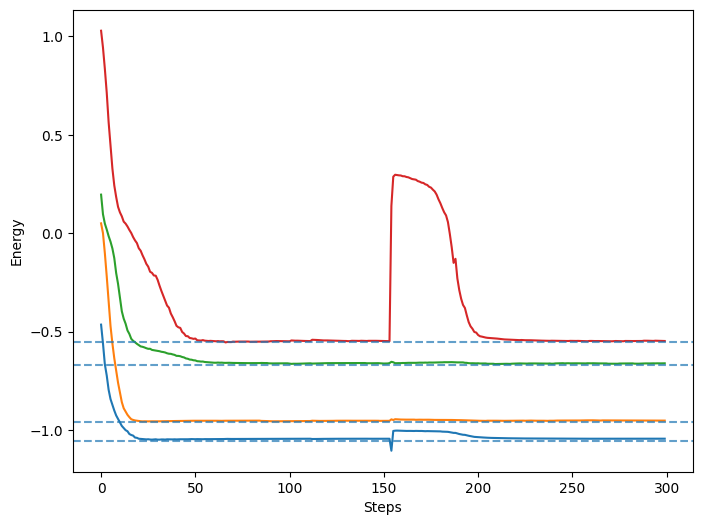

In [8]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(history['steps'],history["Energy_levels"])

for energy_index in range(K):
    ax.axhline(E_fcis[energy_index],linestyle="--", alpha=0.7, label=f"$E_{energy_index}$ (CAS Exact)")



ax.set_ylabel("Energy")
ax.set_xlabel("Steps")